<a href="https://colab.research.google.com/github/Frankieche24/Project-Proposal-ML/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Welcome to Colab!

Section 1 — Imports and configuration

In [1]:
# ============================================================
# Machine Learning for Genotype × Environment Interactions
# in Nigerian Maize Breeding Programs
#
# Course : Practical Machine Learning — MSc Green Data Science
# Institution: ISA, Universidade de Lisboa
# Authors: Olawale Serifdeen Aboderin (29206)
#          Francis Chinaecherem Uzor  (29260)
# Year   : 2026
# ============================================================

# ── Standard library ─────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Core ─────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ── Machine learning ─────────────────────────────────────────
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import Ridge, Lasso
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, GroupKFold, cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import pearsonr
from scipy.cluster.hierarchy import dendrogram, linkage
import xgboost as xgb

# ── Optional interactive map ──────────────────────────────────
try:
    import folium
    HAS_FOLIUM = True
except ImportError:
    HAS_FOLIUM = False
    print("Note: folium not installed — Nigeria map will be skipped. "
          "Install with: pip install folium")

# ── Global settings ───────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['font.size']      = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.dpi']    = 130

print("All libraries loaded successfully.")

All libraries loaded successfully.


Section 2 — Data loading and overview

In [2]:
# ── Load dataset ──────────────────────────────────────────────
# Loaded directly from the project GitHub repository.
# Swap for a local path if preferred:  pd.read_csv('maize_clean.csv')

DATA_URL = "https://raw.githubusercontent.com/Frankieche24/Project-Proposal-ML/main/maize_clean.csv"

df = pd.read_csv(DATA_URL)

# ── Dataset overview ──────────────────────────────────────────
print("=== DATASET OVERVIEW ===")
print(f"Rows:                  {df.shape[0]:,}")
print(f"Columns:               {df.shape[1]}")
print(f"Years:                 {sorted(df['YEAR'].unique())}")
print(f"Locations:             {sorted(df['region'].unique())}")
print(f"Agroecological zones:  {df['agro_ecological_zone'].unique().tolist()}")
print(f"Management conditions: {df['environment_condition'].unique().tolist()}")
print(f"Breeding institutions: {df['breeding_institution'].unique().tolist()}")
print(f"Maturity groups:       {df['maturity_group'].unique().tolist()}")
print(f"Seasons:               {df['season'].unique().tolist()}")
print(f"Total genotypes:       {df['Name'].nunique()}")

print("\nGenotypes per institution:")
print(df.groupby('breeding_institution')['Name'].nunique().to_string())

print("\nObservations per year:")
print(df['YEAR'].value_counts().sort_index().to_string())

print("\nObservations per location:")
print(df['region'].value_counts().to_string())

# ── Missing-value summary ─────────────────────────────────────
# (replaces Colab's display() with a plain print)
overview = pd.DataFrame({
    'Variable':      df.columns,
    'Data Type':     df.dtypes.values,
    'Non-Null Count':df.notnull().sum().values,
    'Missing Count': df.isnull().sum().values,
    'Missing (%)':   (df.isnull().mean() * 100).round(2).values
}).sort_values('Missing (%)', ascending=False)

print("\nMissing values per column:")
print(overview.to_string(index=False))

=== DATASET OVERVIEW ===
Rows:                  21,330
Columns:               38
Years:                 [np.int64(2020), np.int64(2021), np.int64(2022)]
Locations:             ['Ibadan', 'Ilorin', 'Omu-Aran', 'Zaria', 'mokwa']
Agroecological zones:  ['Southern Guinea Savanna', 'Forest–Savanna Transition Zone', 'Northern Guinea Savanna']
Management conditions: ['Optimum', 'Low-N', 'Drought']
Breeding institutions: ['IAR', 'Unilorin', 'CIMMYT and IITA']
Maturity groups:       ['Extra-Early', 'Early', 'late', 'Intermediate']
Seasons:               ['rainy', 'Dry']
Total genotypes:       237

Genotypes per institution:
breeding_institution
CIMMYT and IITA     57
IAR                 80
Unilorin           100

Observations per year:
YEAR
2020    7110
2021    7110
2022    7110

Observations per location:
region
Omu-Aran    4266
Ibadan      4266
Ilorin      4266
Zaria       4266
mokwa       4266

Missing values per column:
                 Variable Data Type  Non-Null Count  Missing Count  Mis

Section 3 — Exploratory data analysis

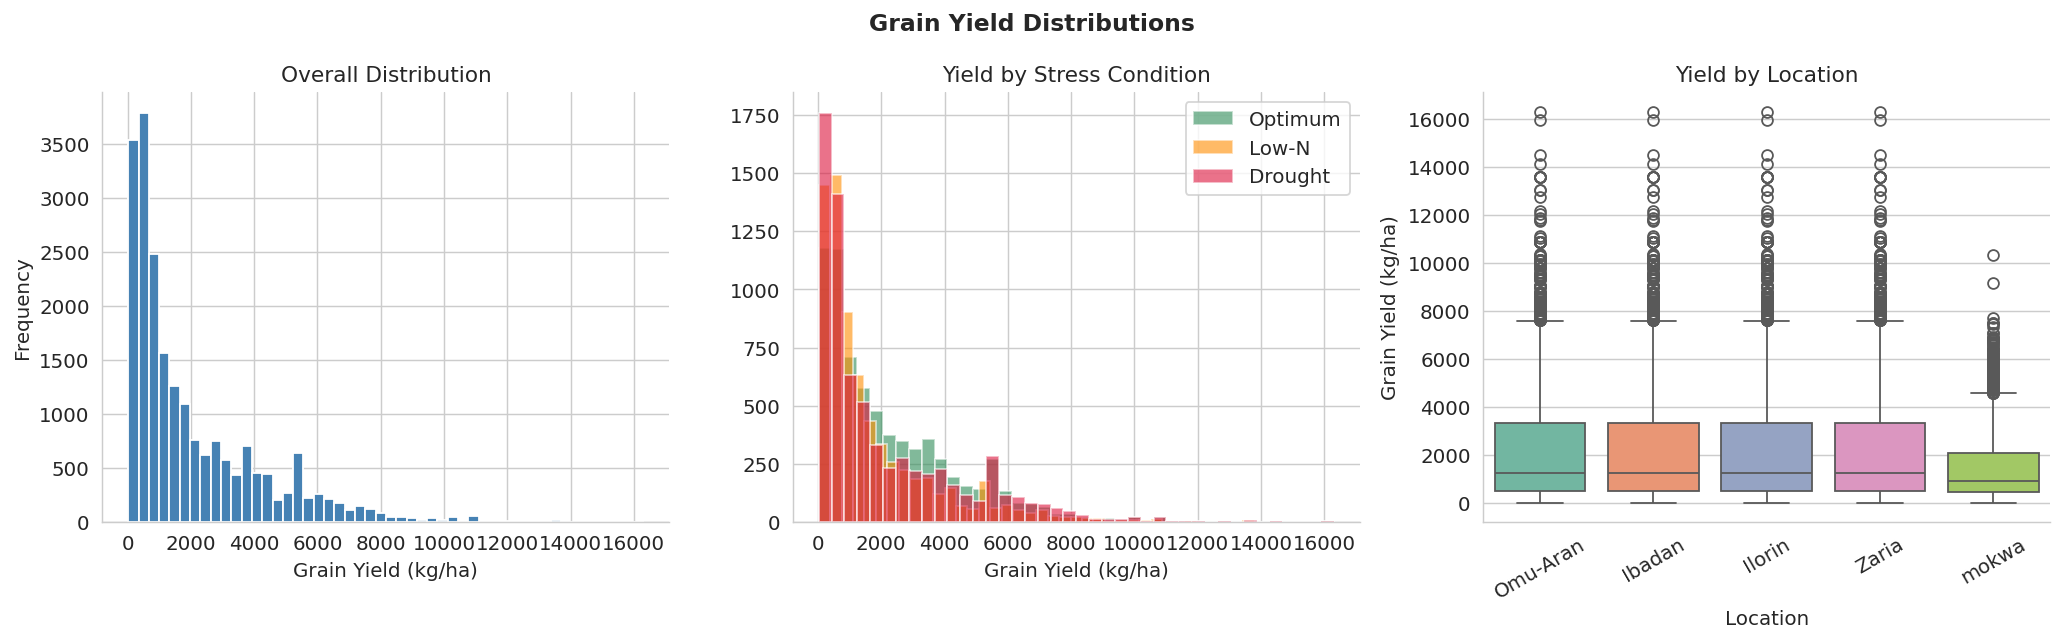

Saved: 01_yield_distributions.png


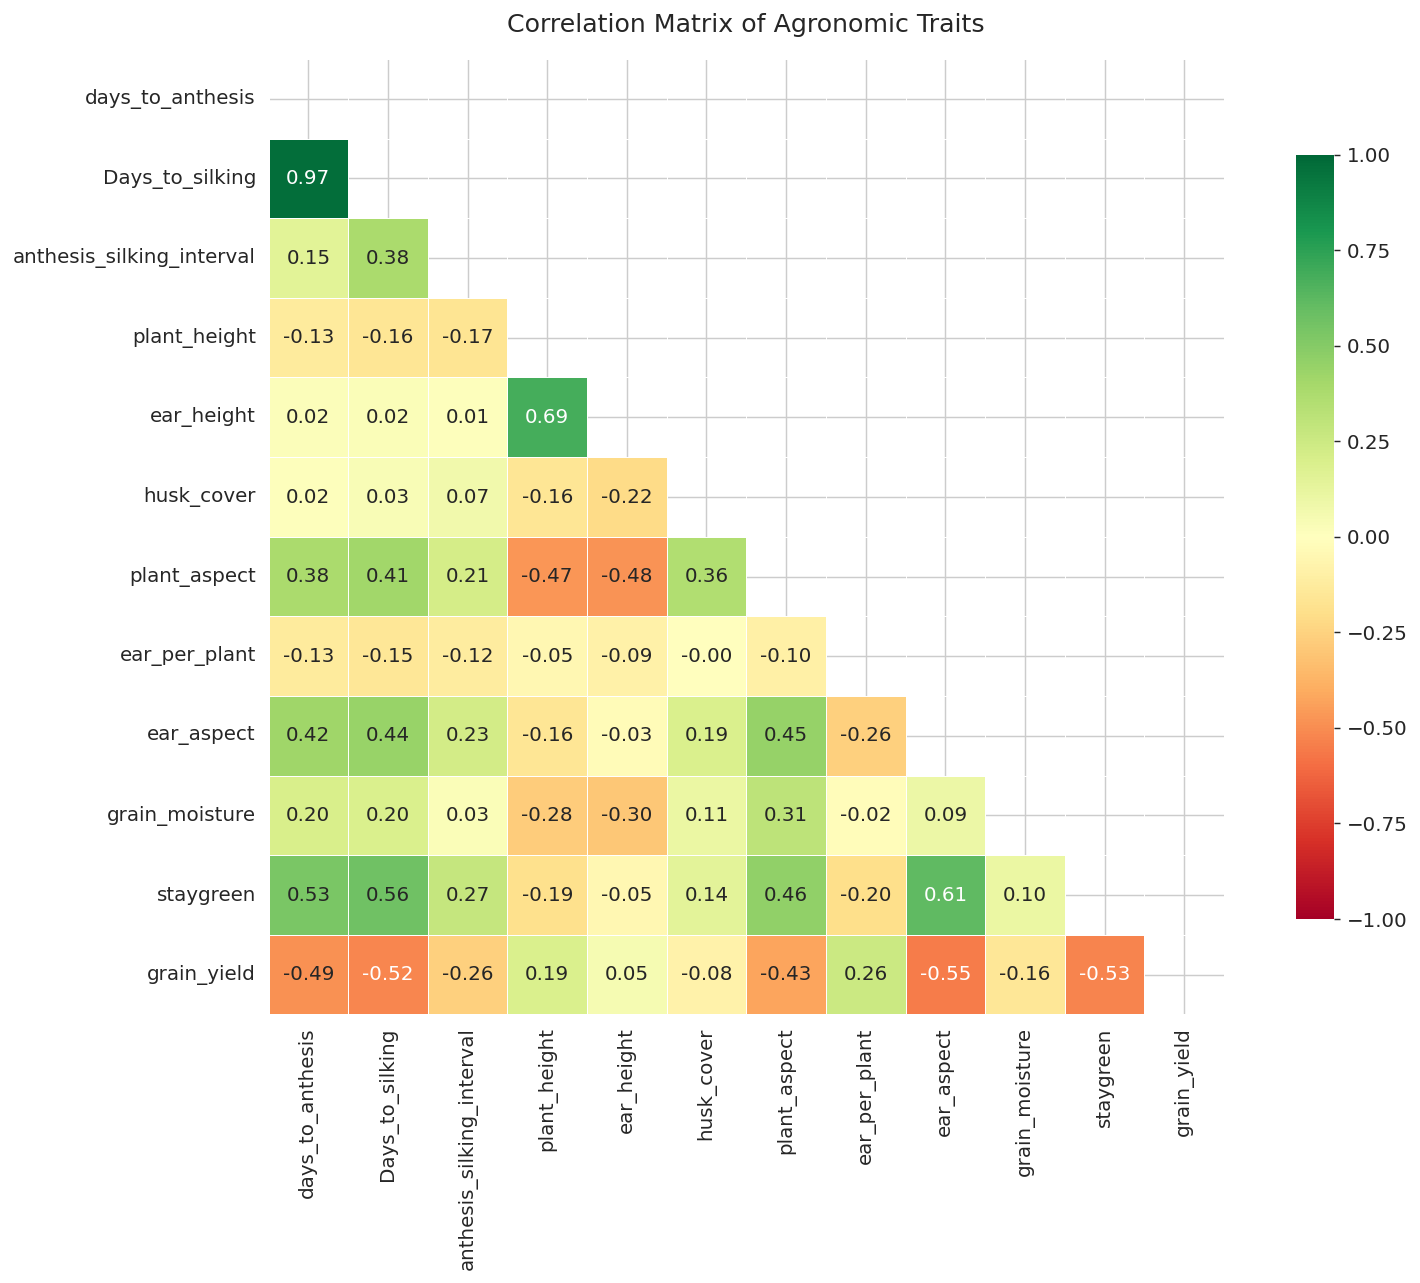

Saved: 02_correlation_heatmap.png


In [3]:
# ── 3a. Yield distributions ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Grain Yield Distributions', fontweight='bold', fontsize=13)

# Overall
axes[0].hist(df['grain_yield'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Overall Distribution')
axes[0].set_xlabel('Grain Yield (kg/ha)')
axes[0].set_ylabel('Frequency')

# By stress condition
for cond, color in zip(['Optimum', 'Low-N', 'Drought'],
                       ['seagreen', 'darkorange', 'crimson']):
    axes[1].hist(df[df['environment_condition'] == cond]['grain_yield'],
                 bins=40, alpha=0.6, label=cond, color=color, edgecolor='white')
axes[1].set_title('Yield by Stress Condition')
axes[1].set_xlabel('Grain Yield (kg/ha)')
axes[1].legend()

# By location — using seaborn for cleaner styling
sns.boxplot(data=df, x='region', y='grain_yield', ax=axes[2], palette='Set2')
axes[2].set_title('Yield by Location')
axes[2].set_xlabel('Location')
axes[2].set_ylabel('Grain Yield (kg/ha)')
axes[2].tick_params(axis='x', rotation=30)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('01_yield_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 01_yield_distributions.png")

# ── 3b. Correlation heatmap ───────────────────────────────────
numeric_cols = [
    'days_to_anthesis', 'Days_to_silking', 'anthesis_silking_interval',
    'plant_height', 'ear_height', 'husk_cover', 'plant_aspect',
    'ear_per_plant', 'ear_aspect', 'grain_moisture', 'staygreen', 'grain_yield'
]

corr_matrix = df[numeric_cols].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix of Agronomic Traits', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 02_correlation_heatmap.png")

Section 4 — Data cleaning and preprocessing

In [4]:
# Standardise location names
df['region'] = df['region'].str.strip().str.title()

# Create unique environment identifier
df['environment_id'] = (df['region'] + '_' +
                        df['environment_condition'] + '_' +
                        df['YEAR'].astype(str))

print(f"Unique environments: {df['environment_id'].nunique()}")
print("Sample IDs:", df['environment_id'].unique()[:4].tolist())

# Impute missing values with column median
for col in ['husk_cover', 'ear_harvested', 'ear_aspect', 'staygreen']:
    if col in df.columns and df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f"Imputed '{col}' with median: {df[col].median():.2f}")

print(f"\nMissing values after imputation: {df.isnull().sum().sum()}")

# Aggregate 2 replications → 1 mean row per genotype-environment
id_cols = [
    'YEAR', 'region', 'agro_ecological_zone', 'season', 'environment_condition',
    'latitude', 'longitude', 'elevation', 'rainfall_mm', 'mean_temperature',
    'soil_type', 'soil_pH', 'soil_N_content', 'soil_P_content', 'soil_K_content',
    'Name', 'Pedigree', 'breeding_institution', 'maturity_group', 'environment_id'
]
agg_cols = [
    'days_to_anthesis', 'Days_to_silking', 'anthesis_silking_interval',
    'plant_height', 'ear_height', 'husk_cover', 'plant_aspect', 'field_weight',
    'ear_harvested', 'ear_per_plant', 'ear_aspect', 'grain_moisture',
    'grain_yield', 'staygreen'
]

# Guard against columns absent in some dataset versions
id_cols  = [c for c in id_cols  if c in df.columns]
agg_cols = [c for c in agg_cols if c in df.columns]

df_agg = df.groupby(id_cols)[agg_cols].mean().reset_index()

print(f"\nBefore aggregation : {df.shape}")
print(f"After aggregation  : {df_agg.shape}")
print("Each row = 1 genotype × 1 environment (mean of replicates)")

Unique environments: 45
Sample IDs: ['Omu-Aran_Optimum_2020', 'Omu-Aran_Optimum_2021', 'Omu-Aran_Optimum_2022', 'Omu-Aran_Low-N_2020']
Imputed 'husk_cover' with median: 2.00
Imputed 'ear_harvested' with median: 6.00
Imputed 'ear_aspect' with median: 3.50
Imputed 'staygreen' with median: 4.00

Missing values after imputation: 0

Before aggregation : (21330, 39)
After aggregation  : (10680, 34)
Each row = 1 genotype × 1 environment (mean of replicates)


Section 5 — Feature engineering

In [5]:
# ── Main effect features ──────────────────────────────────────
df_agg['geno_mean_yield'] = df_agg.groupby('Name')['grain_yield'].transform('mean')
df_agg['env_mean_yield']  = df_agg.groupby('environment_id')['grain_yield'].transform('mean')
df_agg['loc_mean_yield']  = df_agg.groupby('region')['grain_yield'].transform('mean')
print("Mean yield features added.")

# ── Stress Tolerance Index (STI) ──────────────────────────────
# STI = (yield_stress × yield_optimum) / mean_optimum²
opt = (df_agg[df_agg['environment_condition'] == 'Optimum']
       [['Name', 'region', 'YEAR', 'grain_yield']]
       .rename(columns={'grain_yield': 'yield_optimum'}))
df_agg = df_agg.merge(opt, on=['Name', 'region', 'YEAR'], how='left')

mean_opt = (df_agg[df_agg['environment_condition'] == 'Optimum']
            .groupby(['region', 'YEAR'])['grain_yield']
            .mean().rename('mean_opt_yield').reset_index())
df_agg = df_agg.merge(mean_opt, on=['region', 'YEAR'], how='left')

df_agg['stress_tolerance_index'] = (
    (df_agg['grain_yield'] * df_agg['yield_optimum']) /
    (df_agg['mean_opt_yield'] ** 2)
)
# Optimum rows get STI = 1 by definition
df_agg.loc[df_agg['environment_condition'] == 'Optimum', 'stress_tolerance_index'] = 1.0
print("Stress Tolerance Index calculated.")
print(df_agg[['Name', 'region', 'environment_condition',
              'grain_yield', 'stress_tolerance_index']].head(6).to_string(index=False))

# ── Yield stability (CV per genotype) ────────────────────────
df_agg['geno_yield_cv'] = df_agg.groupby('Name')['grain_yield'].transform(
    lambda x: x.std() / x.mean() * 100)

# ── Categorical encoding ──────────────────────────────────────
zone_map      = {'Northern Guinea Savanna': 0,
                 'Southern Guinea Savanna': 1,
                 'Forest–Savanna Transition Zone': 2}
condition_map = {'Drought': 0, 'Low-N': 1, 'Optimum': 2}
maturity_map  = {'Extra-Early': 0, 'Early': 1, 'Intermediate': 2, 'late': 3}
season_map    = {'Dry': 0, 'rainy': 1}
inst_map      = {'IAR': 0, 'Unilorin': 1, 'CIMMYT and IITA': 2}

df_agg['zone_enc']        = df_agg['agro_ecological_zone'].map(zone_map)
df_agg['condition_enc']   = df_agg['environment_condition'].map(condition_map)
df_agg['maturity_enc']    = df_agg['maturity_group'].map(maturity_map)
df_agg['season_enc']      = df_agg['season'].map(season_map)
df_agg['institution_enc'] = df_agg['breeding_institution'].map(inst_map)

le_geno   = LabelEncoder()
le_region = LabelEncoder()
df_agg['geno_enc']   = le_geno.fit_transform(df_agg['Name'])
df_agg['region_enc'] = le_region.fit_transform(df_agg['region'])

# ── Feature list (exact order matters for AMMI-2 column indices) ──
FEATURES = [
    'geno_enc', 'institution_enc', 'maturity_enc',          # indices 0-2
    'region_enc', 'zone_enc', 'condition_enc', 'season_enc', 'YEAR',  # 3-7
    'latitude', 'longitude', 'elevation', 'rainfall_mm', 'mean_temperature',
    'soil_pH', 'soil_N_content', 'soil_P_content', 'soil_K_content',
    'days_to_anthesis', 'Days_to_silking', 'anthesis_silking_interval',
    'plant_height', 'ear_height', 'husk_cover', 'plant_aspect',
    'ear_per_plant', 'ear_aspect', 'grain_moisture', 'staygreen',
    'geno_mean_yield', 'env_mean_yield', 'loc_mean_yield',
    'stress_tolerance_index', 'geno_yield_cv'
]
# Drop any feature absent in the current dataframe
FEATURES = [f for f in FEATURES if f in df_agg.columns]

# Final NaN fill (safety net)
for col in FEATURES:
    if df_agg[col].isnull().sum() > 0:
        df_agg[col] = df_agg[col].fillna(df_agg[col].median())

TARGET = 'grain_yield'
X = df_agg[FEATURES].copy()
y = df_agg[TARGET].copy()

print(f"\nFeature matrix : {X.shape}  |  Target: {y.shape}")
print(f"NaN in features: {X.isnull().sum().sum()} (should be 0)")
print(f"\nFeatures ({len(FEATURES)}):")
for f in FEATURES:
    print(f"  - {f}")

Mean yield features added.
Stress Tolerance Index calculated.
     Name region environment_condition  grain_yield  stress_tolerance_index
ILOMAZ-01 Ibadan               Drought     2446.100                0.885088
ILOMAZ-02 Ibadan               Drought     2758.275                3.849728
ILOMAZ-03 Ibadan               Drought     2838.800                0.427826
ILOMAZ-04 Ibadan               Drought     2990.210                2.117599
ILOMAZ-05 Ibadan               Drought     1750.455                0.231987
ILOMAZ-06 Ibadan               Drought     3579.555                2.505448

Feature matrix : (10710, 33)  |  Target: (10710,)
NaN in features: 0 (should be 0)

Features (33):
  - geno_enc
  - institution_enc
  - maturity_enc
  - region_enc
  - zone_enc
  - condition_enc
  - season_enc
  - YEAR
  - latitude
  - longitude
  - elevation
  - rainfall_mm
  - mean_temperature
  - soil_pH
  - soil_N_content
  - soil_P_content
  - soil_K_content
  - days_to_anthesis
  - Days_to_silkin

Section 6 — AMMI-2 baseline class

In [6]:
class AMMI2Regressor(BaseEstimator, RegressorMixin):
    """
    Scikit-learn-compatible AMMI-2 regressor.

    Decomposes grain yield into:
        grand_mean + genotype_effect + environment_effect
        + rank-2 SVD interaction term

    Column positions assumed in FEATURES (0-indexed):
        geno_enc    → index 0
        region_enc  → index 3
        condition_enc → index 5
    These are used to identify genotype and environment in fit/predict.
    """

    def __init__(self, n_components=2):
        self.n_components = n_components

    def fit(self, X, y):
        X_arr    = X.values if hasattr(X, 'values') else X
        y_vals   = y.values if hasattr(y, 'values') else y

        geno_idx = X_arr[:, 0].astype(int)
        env_idx  = X_arr[:, 3].astype(int) * 10 + X_arr[:, 5].astype(int)

        self.grand_mean_   = float(y_vals.mean())
        self.geno_effects_ = {g: float(y_vals[geno_idx == g].mean()) - self.grand_mean_
                              for g in np.unique(geno_idx)}
        self.env_effects_  = {e: float(y_vals[env_idx == e].mean()) - self.grand_mean_
                              for e in np.unique(env_idx)}

        residuals = (y_vals
                     - self.grand_mean_
                     - np.array([self.geno_effects_.get(g, 0) for g in geno_idx])
                     - np.array([self.env_effects_.get(e, 0)  for e in env_idx]))

        geno_list   = sorted(np.unique(geno_idx))
        env_list    = sorted(np.unique(env_idx))
        self.g_map_ = {g: i for i, g in enumerate(geno_list)}
        self.e_map_ = {e: i for i, e in enumerate(env_list)}

        R      = np.zeros((len(geno_list), len(env_list)))
        counts = np.zeros_like(R)
        for i in range(len(y_vals)):
            gi = self.g_map_[geno_idx[i]]
            ei = self.e_map_[env_idx[i]]
            R[gi, ei]      += residuals[i]
            counts[gi, ei] += 1
        R[counts > 0] /= counts[counts > 0]

        U, s, Vt    = np.linalg.svd(R, full_matrices=False)
        self.U_     = U[:, :self.n_components]
        self.s_     = s[:self.n_components]
        self.Vt_    = Vt[:self.n_components, :]

        var_exp = np.cumsum(s ** 2 / np.sum(s ** 2) * 100)
        print(f"  [AMMI-{self.n_components}] Interaction variance explained: "
              f"{var_exp[self.n_components - 1]:.1f}%")
        return self

    def predict(self, X):
        X_arr    = X.values if hasattr(X, 'values') else X
        geno_idx = X_arr[:, 0].astype(int)
        env_idx  = X_arr[:, 3].astype(int) * 10 + X_arr[:, 5].astype(int)

        preds = np.zeros(len(X_arr))
        for i in range(len(X_arr)):
            g    = geno_idx[i]
            e    = env_idx[i]
            pred = (self.grand_mean_
                    + self.geno_effects_.get(g, 0)
                    + self.env_effects_.get(e, 0))
            if g in self.g_map_ and e in self.e_map_:
                gi    = self.g_map_[g]
                ei    = self.e_map_[e]
                pred += float(np.sum(self.s_ * self.U_[gi, :] * self.Vt_[:, ei]))
            preds[i] = pred
        return preds

print("AMMI2Regressor class defined.")

AMMI2Regressor class defined.


Section 7 — Cross-validation schemes and helper functions

In [7]:
# CV1: Random 5-fold (easiest — general accuracy)
cv1 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# CV2: Leave-one-environment-out (realistic — new location)
cv2_groups = df_agg['environment_id'].values
cv2        = GroupKFold(n_splits=df_agg['environment_id'].nunique())

# CV0: Leave-one-genotype-group-out (hardest — new variety)
cv0_groups = df_agg['Name'].values
cv0        = GroupKFold(n_splits=10)

print("Cross-validation schemes defined:")
print(f"  CV1 (random 5-fold)      : 5 folds")
print(f"  CV2 (leave-environment)  : {df_agg['environment_id'].nunique()} folds")
print(f"  CV0 (leave-genotype)     : 10 folds")


def evaluate_predictions(y_true, y_pred, model_name, cv_name):
    """Return dict with RMSE, R², and Pearson r."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    r, _ = pearsonr(y_true, y_pred)
    return {
        'Model':        model_name,
        'CV Scheme':    cv_name,
        'RMSE (kg/ha)': round(rmse, 2),
        'R²':           round(r2, 4),
        'Pearson r':    round(r, 4)
    }


def run_cv(model, X, y, cv, groups=None, model_name='Model', cv_name='CV'):
    """
    Wrap model in a StandardScaler pipeline and run cross_val_predict.
    AMMI-2 skips scaling because it uses raw integer-encoded indices.
    """
    if model_name == 'AMMI-2':
        pipeline = Pipeline([('model', model)])
    else:
        pipeline = Pipeline([('scaler', StandardScaler()), ('model', model)])
    y_pred = cross_val_predict(pipeline, X, y, cv=cv, groups=groups)
    return evaluate_predictions(y, y_pred, model_name, cv_name), y_pred


print("Helper functions defined.")

Cross-validation schemes defined:
  CV1 (random 5-fold)      : 5 folds
  CV2 (leave-environment)  : 45 folds
  CV0 (leave-genotype)     : 10 folds
Helper functions defined.


Section 8 — Model definitions

In [8]:
models = {
    # Classical baseline
    'AMMI-2': AMMI2Regressor(n_components=2),

    # Linear ML
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=1.0, max_iter=5000),

    # Non-linear ML
    'SVR': SVR(kernel='rbf', C=10, epsilon=0.1),
    'RandomForest': RandomForestRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
}

print(f"{len(models)} models defined:")
print("  Classical baseline : AMMI-2")
print("  ML models          :", [k for k in models if k != 'AMMI-2'])

6 models defined:
  Classical baseline : AMMI-2
  ML models          : ['Ridge', 'Lasso', 'SVR', 'RandomForest', 'XGBoost']


Section 9 — Run all models across all CV schemes

In [9]:
all_results     = []
all_predictions = {}

cv_schemes = {
    'CV1 (Random)':     (cv1, None),
    'CV2 (Leave-Env)':  (cv2, cv2_groups),
    'CV0 (Leave-Geno)': (cv0, cv0_groups)
}

print("Running all models across all CV schemes...")
print("=" * 62)

for model_name, model in models.items():
    all_predictions[model_name] = {}
    print(f"\n{model_name}:")
    for cv_name, (cv_obj, groups) in cv_schemes.items():
        print(f"  {cv_name} ...", end=' ', flush=True)
        metrics, y_pred = run_cv(
            model, X, y, cv=cv_obj,
            groups=groups, model_name=model_name, cv_name=cv_name)
        all_results.append(metrics)
        all_predictions[model_name][cv_name] = y_pred
        print(f"RMSE={metrics['RMSE (kg/ha)']:.1f}  "
              f"R²={metrics['R²']:.3f}  "
              f"r={metrics['Pearson r']:.3f}")

results_df = pd.DataFrame(all_results)
results_df.to_csv('model_results.csv', index=False)
print(f"\n{'='*62}")
print(f"Done — {len(results_df)} model × CV combinations. "
      f"Saved: model_results.csv")

Running all models across all CV schemes...

AMMI-2:
  CV1 (Random) ...   [AMMI-2] Interaction variance explained: 27.9%
  [AMMI-2] Interaction variance explained: 27.8%
  [AMMI-2] Interaction variance explained: 27.5%
  [AMMI-2] Interaction variance explained: 28.0%
  [AMMI-2] Interaction variance explained: 30.1%
RMSE=1773.3  R²=0.013  r=0.272
  CV2 (Leave-Env) ...   [AMMI-2] Interaction variance explained: 32.1%
  [AMMI-2] Interaction variance explained: 30.5%
  [AMMI-2] Interaction variance explained: 30.4%
  [AMMI-2] Interaction variance explained: 31.2%
  [AMMI-2] Interaction variance explained: 31.8%
  [AMMI-2] Interaction variance explained: 30.9%
  [AMMI-2] Interaction variance explained: 32.3%
  [AMMI-2] Interaction variance explained: 35.7%
  [AMMI-2] Interaction variance explained: 31.1%
  [AMMI-2] Interaction variance explained: 31.1%
  [AMMI-2] Interaction variance explained: 31.0%
  [AMMI-2] Interaction variance explained: 30.8%
  [AMMI-2] Interaction variance explained:

Section 10 — Results: tables, bar charts, predicted vs observed, feature importance


=== MODEL PERFORMANCE COMPARISON ===

RMSE (kg/ha) — lower is better:
CV Scheme     CV0 (Leave-Geno)  CV1 (Random)  CV2 (Leave-Env)
Model                                                        
AMMI-2                  1663.8        1773.4           1885.5
Lasso                   1145.5        1146.9           1174.8
RandomForest             989.8         994.0           1052.0
Ridge                   1145.1        1146.6           1177.5
SVR                     1303.0        1322.6           1336.0
XGBoost                  948.7         959.1           1023.7

R² — higher is better:
CV Scheme     CV0 (Leave-Geno)  CV1 (Random)  CV2 (Leave-Env)
Model                                                        
AMMI-2                   0.131         0.013           -0.116
Lasso                    0.588         0.587            0.567
RandomForest             0.692         0.690            0.653
Ridge                    0.588         0.587            0.565
SVR                      0.467       

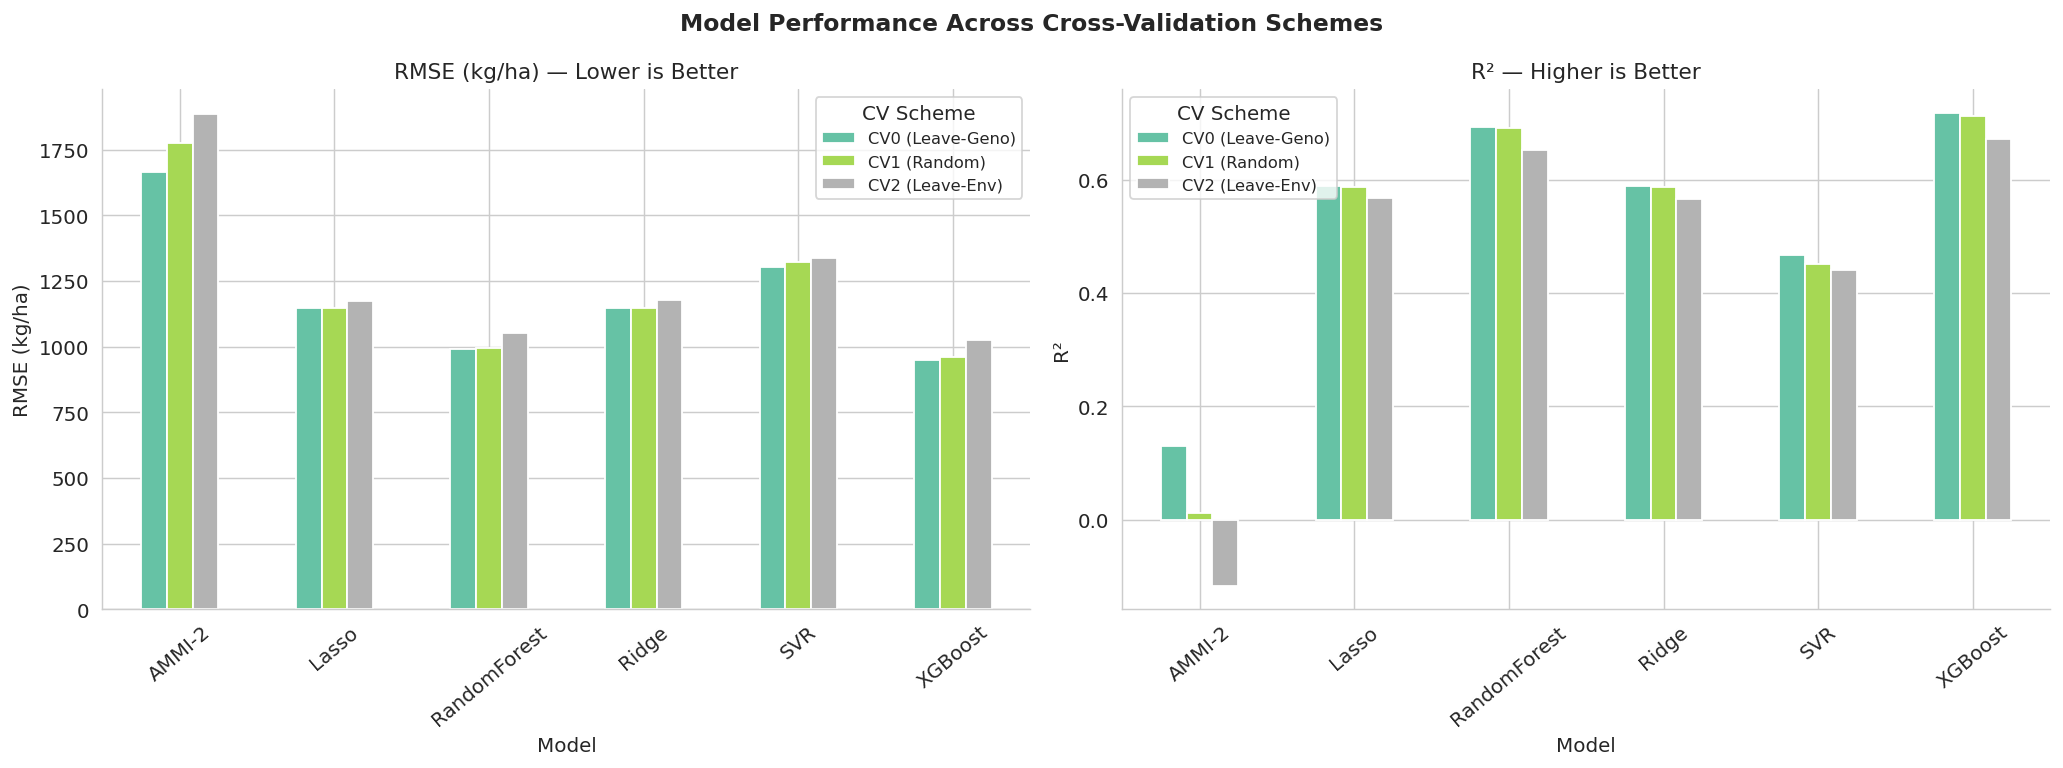

Saved: 03_model_comparison.png


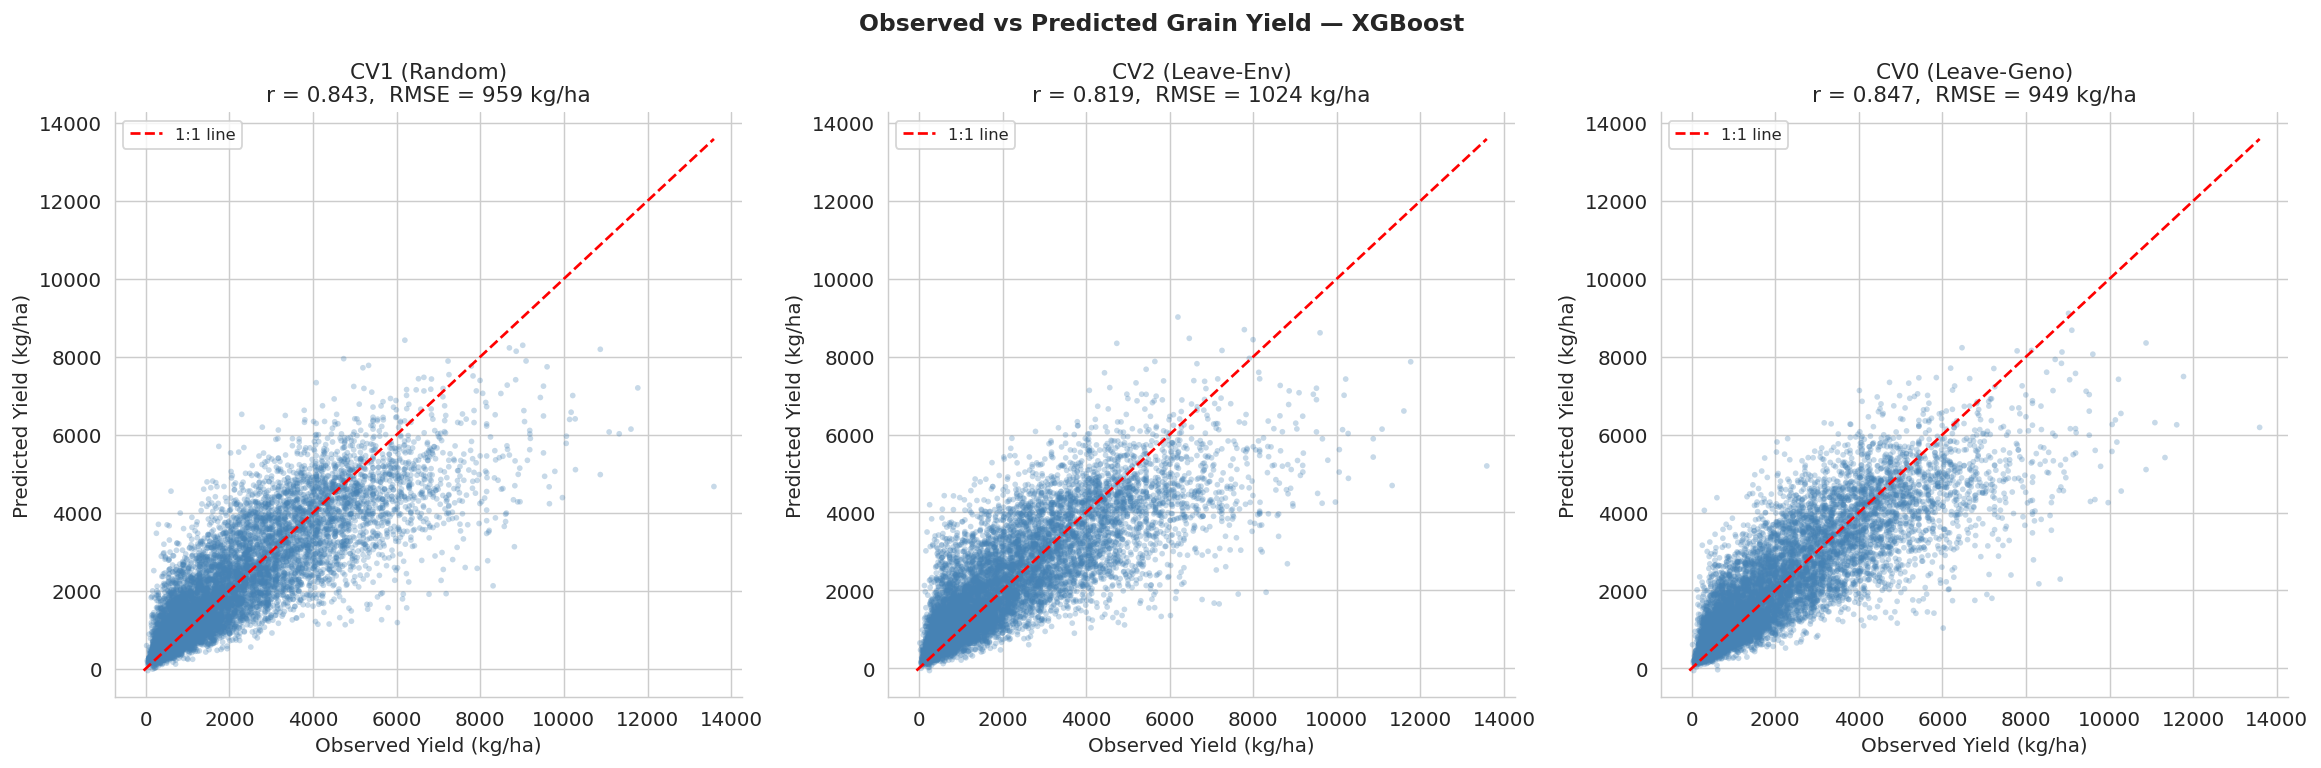

Saved: 04_observed_vs_predicted.png


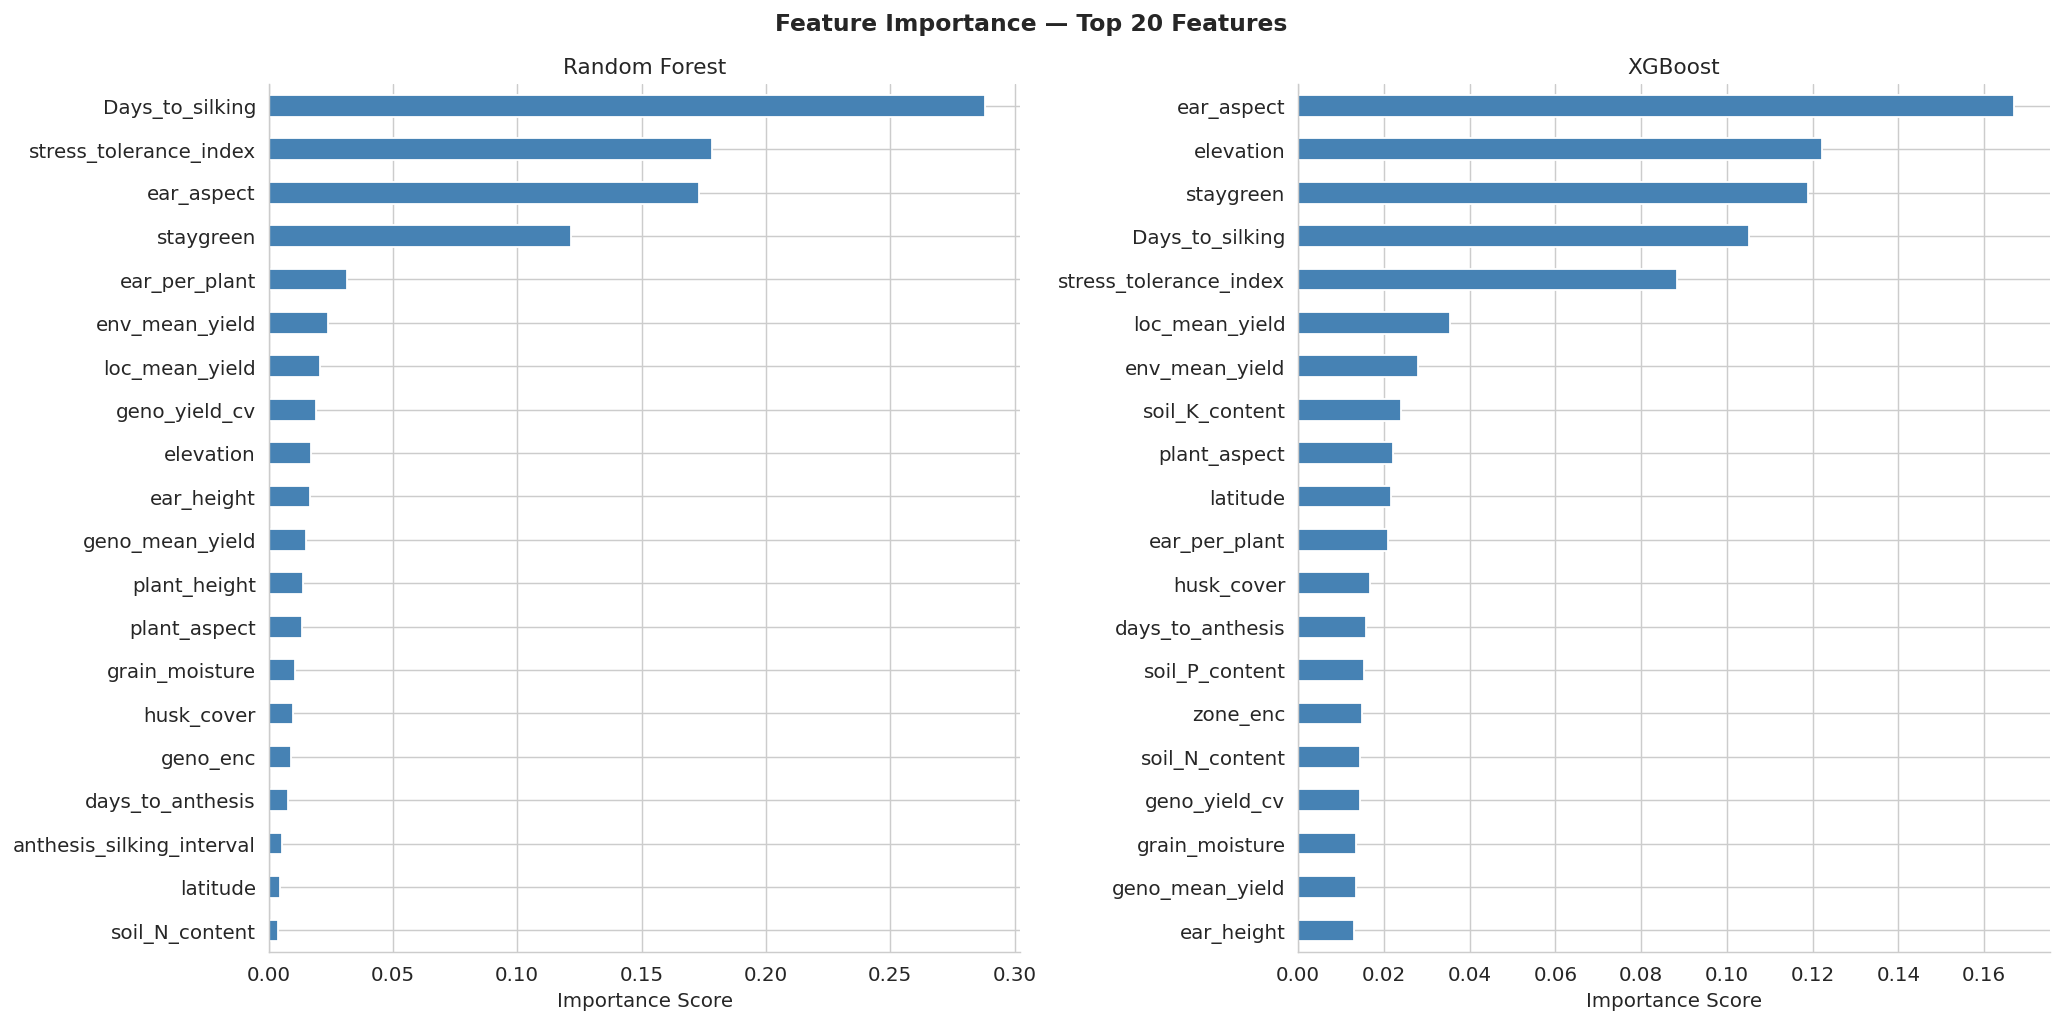

Saved: 05_feature_importance.png

Models saved to disk: xgb_model.pkl | scaler.pkl | le_geno.pkl | le_region.pkl


In [10]:
# ── 10a. Performance pivot tables ────────────────────────────
print("\n=== MODEL PERFORMANCE COMPARISON ===\n")

rmse_pivot = results_df.pivot(index='Model', columns='CV Scheme', values='RMSE (kg/ha)')
r2_pivot   = results_df.pivot(index='Model', columns='CV Scheme', values='R²')

print("RMSE (kg/ha) — lower is better:")
print(rmse_pivot.round(1).to_string())
print("\nR² — higher is better:")
print(r2_pivot.round(3).to_string())

print("\nBest model per CV scheme (lowest RMSE):")
for cv in results_df['CV Scheme'].unique():
    sub  = results_df[results_df['CV Scheme'] == cv]
    best = sub.loc[sub['RMSE (kg/ha)'].idxmin()]
    print(f"  {cv}: {best['Model']} "
          f"(RMSE={best['RMSE (kg/ha)']:.1f}, R²={best['R²']:.3f})")

# ── 10b. Bar charts: RMSE and R² ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Model Performance Across Cross-Validation Schemes',
             fontweight='bold', fontsize=13)

rmse_pivot.plot(kind='bar', ax=axes[0], colormap='Set2', edgecolor='white')
axes[0].set_title('RMSE (kg/ha) — Lower is Better')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE (kg/ha)')
axes[0].legend(title='CV Scheme', fontsize=9)
axes[0].tick_params(axis='x', rotation=40)
axes[0].spines[['top', 'right']].set_visible(False)

r2_pivot.plot(kind='bar', ax=axes[1], colormap='Set2', edgecolor='white')
axes[1].set_title('R² — Higher is Better')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R²')
axes[1].legend(title='CV Scheme', fontsize=9)
axes[1].tick_params(axis='x', rotation=40)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 03_model_comparison.png")

# ── 10c. Observed vs Predicted — XGBoost, 3 CV schemes ───────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Observed vs Predicted Grain Yield — XGBoost',
             fontweight='bold', fontsize=13)

for ax, cv_name in zip(axes, ['CV1 (Random)', 'CV2 (Leave-Env)', 'CV0 (Leave-Geno)']):
    y_pred   = all_predictions['XGBoost'][cv_name]
    r, _     = pearsonr(y, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y, y_pred))
    lim      = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]

    ax.scatter(y, y_pred, alpha=0.3, s=10, color='steelblue', edgecolors='none')
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='1:1 line')
    ax.set_xlabel('Observed Yield (kg/ha)')
    ax.set_ylabel('Predicted Yield (kg/ha)')
    ax.set_title(f'{cv_name}\nr = {r:.3f},  RMSE = {rmse_val:.0f} kg/ha')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('04_observed_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 04_observed_vs_predicted.png")

# ── 10d. Train on full data for feature importance + deployment ──
scaler_full    = StandardScaler()
X_scaled_full  = scaler_full.fit_transform(X)

xgb_model_full = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_STATE, verbosity=0)
xgb_model_full.fit(X_scaled_full, y)

rf_model_full = RandomForestRegressor(
    n_estimators=200, max_depth=10, min_samples_leaf=5,
    random_state=RANDOM_STATE, n_jobs=-1)
rf_model_full.fit(X_scaled_full, y)

# ── 10e. Feature importance ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Feature Importance — Top 20 Features', fontweight='bold', fontsize=13)

for ax, (model_obj, label) in zip(axes, [
        (rf_model_full,  'Random Forest'),
        (xgb_model_full, 'XGBoost')]):
    imp = pd.Series(model_obj.feature_importances_, index=FEATURES)
    imp.sort_values(ascending=True).tail(20).plot(
        kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(label)
    ax.set_xlabel('Importance Score')
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('05_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 05_feature_importance.png")

# ── 10f. Save models (replaces Colab's files.download) ───────
joblib.dump(xgb_model_full, 'xgb_model.pkl')
joblib.dump(scaler_full,    'scaler.pkl')
joblib.dump(le_geno,        'le_geno.pkl')
joblib.dump(le_region,      'le_region.pkl')
print("\nModels saved to disk: xgb_model.pkl | scaler.pkl | "
      "le_geno.pkl | le_region.pkl")

Section 11 — Location clustering and trial network optimisation

Location performance matrix: (5, 237)
Locations: ['Ibadan', 'Ilorin', 'Mokwa', 'Omu-Aran', 'Zaria']
  k=2: Silhouette Score = 0.1282
  k=3: Silhouette Score = 0.0196
  k=4: Silhouette Score = 0.0091

Optimal number of clusters: 2

Location cluster assignments:
Location  Cluster  Latitude  Longitude
  Ibadan        1    7.3775      3.947
  Ilorin        1    8.5000      4.550
   Mokwa        0    9.3000      5.050
Omu-Aran        1    8.1400      5.100
   Zaria        1   11.0667      7.700


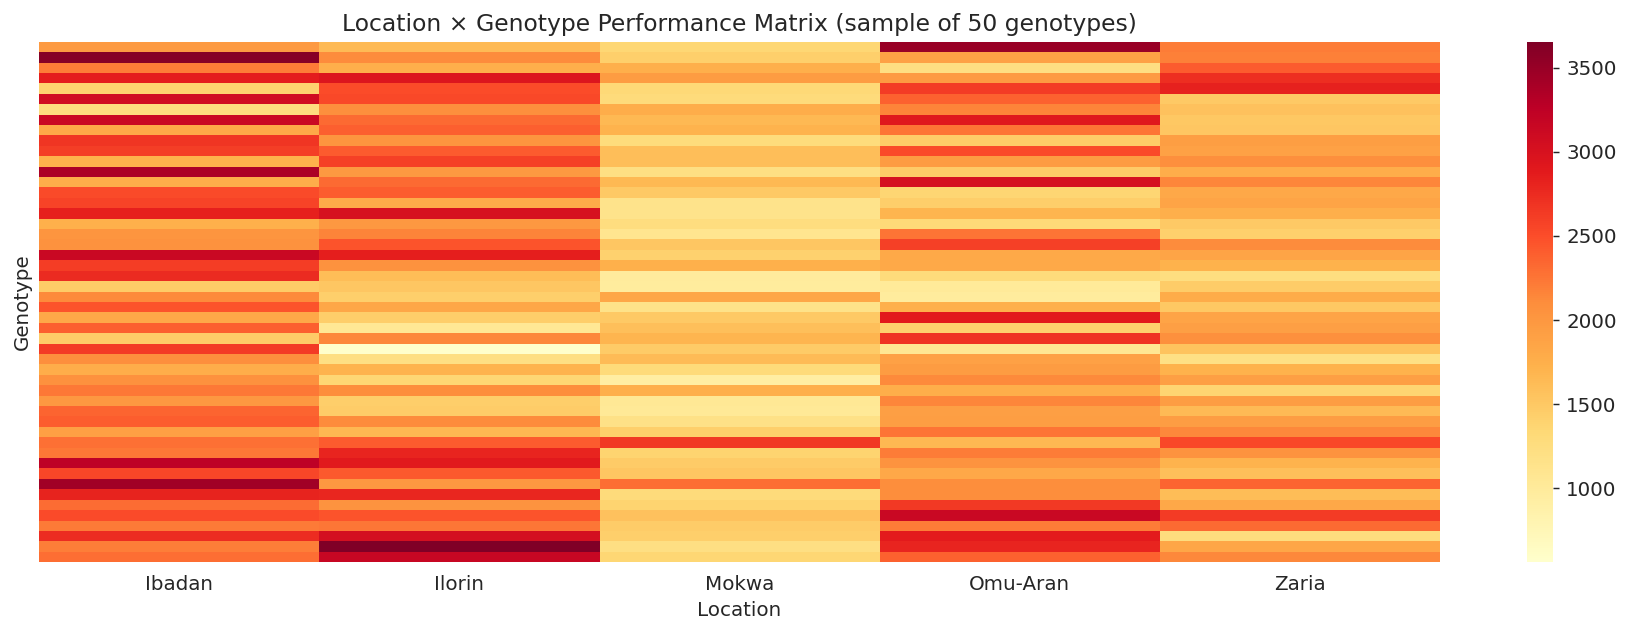

Saved: 06_location_genotype_heatmap.png
Saved: 07_nigeria_location_clusters.html


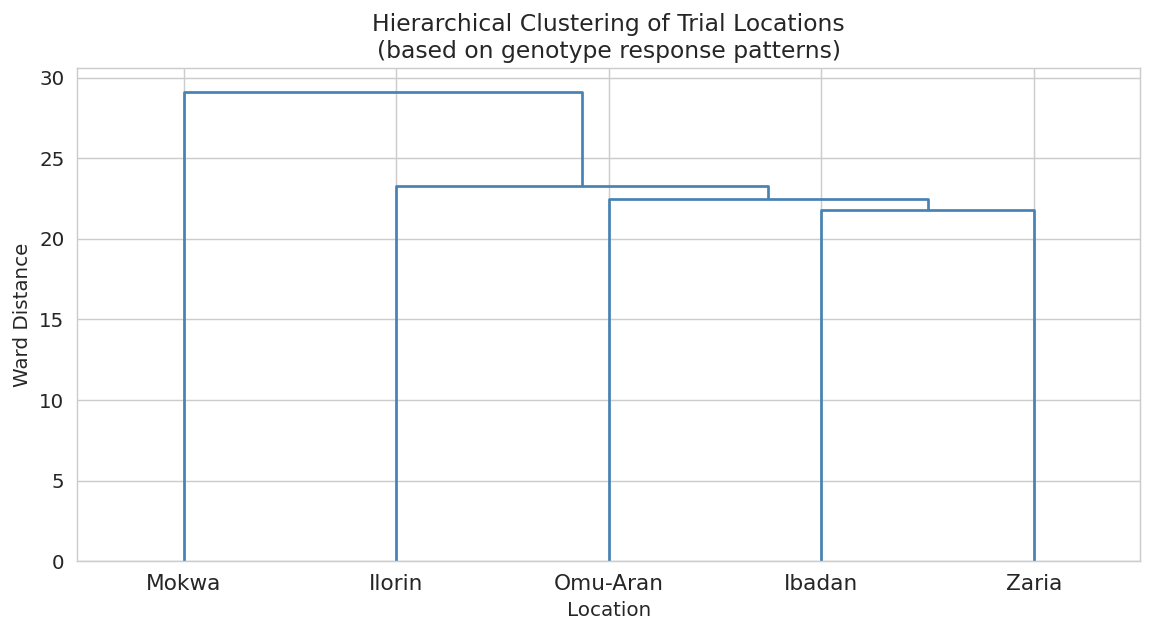

Saved: 08_location_dendrogram.png

=== TRIAL NETWORK OPTIMISATION ===
Baseline RMSE (all locations): 959.1 kg/ha

  Drop Ibadan              : RMSE=962.4  (change: +3.3 kg/ha)  [Low]
  Drop Ilorin              : RMSE=965.2  (change: +6.1 kg/ha)  [Low]
  Drop Mokwa               : RMSE=1024.1  (change: +64.9 kg/ha)  [Medium]
  Drop Omu-Aran            : RMSE=958.3  (change: -0.8 kg/ha)  [Low]
  Drop Zaria               : RMSE=963.2  (change: +4.1 kg/ha)  [Low]

Locations ranked by redundancy (smallest change = most redundant):
Location Dropped  RMSE Without  RMSE Change Impact
        Omu-Aran         958.3         -0.8    Low
          Ibadan         962.4          3.3    Low
           Zaria         963.2          4.1    Low
          Ilorin         965.2          6.1    Low
           Mokwa        1024.1         64.9 Medium


In [11]:
# ── 11a. Location × genotype performance matrix ───────────────
location_matrix = df_agg.pivot_table(
    index='region', columns='Name',
    values='grain_yield', aggfunc='mean')
location_matrix = location_matrix.fillna(location_matrix.mean())

print(f"Location performance matrix: {location_matrix.shape}")
print("Locations:", location_matrix.index.tolist())

scaler_loc = StandardScaler()
loc_scaled = scaler_loc.fit_transform(location_matrix)

# ── 11b. Silhouette analysis ──────────────────────────────────
silhouette_scores = []
k_range           = range(2, min(5, len(location_matrix)))

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(loc_scaled)
    score  = silhouette_score(loc_scaled, labels)
    silhouette_scores.append(score)
    print(f"  k={k}: Silhouette Score = {score:.4f}")

optimal_k = list(k_range)[int(np.argmax(silhouette_scores))]
print(f"\nOptimal number of clusters: {optimal_k}")

# ── 11c. K-Means with optimal k ──────────────────────────────
km_final          = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=10)
location_clusters = km_final.fit_predict(loc_scaled)

coords = (df_agg.groupby('region')[['latitude', 'longitude']]
          .mean().reset_index()
          .rename(columns={'region': 'Location',
                            'latitude': 'Latitude',
                            'longitude': 'Longitude'}))

location_cluster_df = (pd.DataFrame({
    'Location': location_matrix.index,
    'Cluster':  location_clusters})
    .merge(coords, on='Location'))

print("\nLocation cluster assignments:")
print(location_cluster_df.to_string(index=False))

# ── 11d. Heatmap: location × genotype ────────────────────────
plt.figure(figsize=(14, 5))
sns.heatmap(location_matrix.T.head(50), cmap='YlOrRd',
            linewidths=0, yticklabels=False)
plt.title('Location × Genotype Performance Matrix (sample of 50 genotypes)',
          fontsize=13)
plt.xlabel('Location')
plt.ylabel('Genotype')
plt.tight_layout()
plt.savefig('06_location_genotype_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 06_location_genotype_heatmap.png")

# ── 11e. Interactive Nigeria map (folium) ─────────────────────
if HAS_FOLIUM:
    cluster_colors = ['red', 'blue', 'green', 'purple', 'orange']
    nigeria_map    = folium.Map(location=[9.5, 8.0], zoom_start=6,
                                tiles='CartoDB positron')
    for _, row in location_cluster_df.iterrows():
        color = cluster_colors[int(row['Cluster'])]
        folium.CircleMarker(
            location=[row['Latitude'], row['Longitude']],
            radius=15, color=color, fill=True,
            fill_color=color, fill_opacity=0.8,
            popup=folium.Popup(
                f"<b>{row['Location']}</b><br>Cluster: {row['Cluster']}",
                max_width=200),
            tooltip=f"{row['Location']} (Cluster {row['Cluster']})"
        ).add_to(nigeria_map)
    nigeria_map.save('07_nigeria_location_clusters.html')
    print("Saved: 07_nigeria_location_clusters.html")
else:
    print("Skipping Nigeria map (folium not installed).")

# ── 11f. Hierarchical clustering dendrogram ──────────────────
linked = linkage(loc_scaled, method='ward')

plt.figure(figsize=(9, 5))
dendrogram(linked, labels=location_matrix.index.tolist(),
           color_threshold=0, above_threshold_color='steelblue')
plt.title('Hierarchical Clustering of Trial Locations\n'
          '(based on genotype response patterns)', fontsize=13)
plt.xlabel('Location')
plt.ylabel('Ward Distance')
plt.tight_layout()
plt.savefig('08_location_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 08_location_dendrogram.png")

# ── 11g. Drop-one-location analysis ──────────────────────────
baseline_rmse = results_df[
    (results_df['Model']     == 'XGBoost') &
    (results_df['CV Scheme'] == 'CV1 (Random)')
]['RMSE (kg/ha)'].values[0]

print(f"\n=== TRIAL NETWORK OPTIMISATION ===")
print(f"Baseline RMSE (all locations): {baseline_rmse:.1f} kg/ha\n")

drop_results = []
for loc in df_agg['region'].unique():
    df_red = df_agg[df_agg['region'] != loc]
    X_red  = df_red[FEATURES].fillna(df_red[FEATURES].median())
    y_red  = df_red[TARGET]
    pipe   = Pipeline([
        ('scaler', StandardScaler()),
        ('model', xgb.XGBRegressor(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            random_state=RANDOM_STATE, verbosity=0))
    ])
    y_pred_red = cross_val_predict(
        pipe, X_red, y_red,
        cv=KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE))
    rmse_red = np.sqrt(mean_squared_error(y_red, y_pred_red))
    change   = rmse_red - baseline_rmse
    impact   = ('Low'    if abs(change) < 50  else
                'Medium' if abs(change) < 150 else 'High')
    drop_results.append({
        'Location Dropped': loc,
        'RMSE Without':     round(rmse_red, 1),
        'RMSE Change':      round(change, 1),
        'Impact':           impact
    })
    print(f"  Drop {loc:20s}: RMSE={rmse_red:.1f}  "
          f"(change: {change:+.1f} kg/ha)  [{impact}]")

drop_df = pd.DataFrame(drop_results).sort_values('RMSE Change')
print("\nLocations ranked by redundancy (smallest change = most redundant):")
print(drop_df.to_string(index=False))

Section 12 — Analysis and discussion

In [12]:
# ── 12a. CV difficulty progression ───────────────────────────
print("=== PREDICTION DIFFICULTY ACROSS CV SCHEMES ===\n")
print("CV1 = random split (easiest — data leakage between train/test)")
print("CV2 = new environment (realistic — entire location withheld)")
print("CV0 = new genotype   (hardest   — entire variety withheld)\n")

for model_name in models:
    r1 = results_df[(results_df['Model'] == model_name) &
                    (results_df['CV Scheme'] == 'CV1 (Random)'    )]['RMSE (kg/ha)'].values[0]
    r2 = results_df[(results_df['Model'] == model_name) &
                    (results_df['CV Scheme'] == 'CV2 (Leave-Env)' )]['RMSE (kg/ha)'].values[0]
    r0 = results_df[(results_df['Model'] == model_name) &
                    (results_df['CV Scheme'] == 'CV0 (Leave-Geno)')]['RMSE (kg/ha)'].values[0]
    print(f"{model_name:15s}: CV1={r1:.0f}  →  CV2={r2:.0f}  →  CV0={r0:.0f} kg/ha")

# ── 12b. Genotype rankings ────────────────────────────────────
geno_stats = df_agg.groupby('Name').agg(
    mean_yield=('grain_yield', 'mean'),
    cv_yield  =('grain_yield', lambda x: x.std() / x.mean() * 100),
    mean_sti  =('stress_tolerance_index', 'mean'),
    n_envs    =('environment_id', 'nunique')
).reset_index()

geno_stats['adaptation_score'] = (
    geno_stats['mean_yield'] / geno_stats['mean_yield'].max() -
    geno_stats['cv_yield']   / geno_stats['cv_yield'].max()
)

print("\n=== TOP 10 BROADLY ADAPTED GENOTYPES ===")
print("(High mean yield + Low yield variability across environments)")
top_broad = geno_stats.nlargest(10, 'adaptation_score')
print(top_broad[['Name', 'mean_yield', 'cv_yield', 'mean_sti']]
      .round(2).to_string(index=False))

print("\n=== TOP 10 STRESS-TOLERANT GENOTYPES ===")
top_stress = geno_stats.nlargest(10, 'mean_sti')
print(top_stress[['Name', 'mean_yield', 'mean_sti', 'cv_yield']]
      .round(3).to_string(index=False))

# ── 12c. Yield reduction under stress by agroecological zone ──
stress_pivot = (
    df_agg.groupby(['agro_ecological_zone', 'environment_condition'])
    ['grain_yield'].mean().reset_index()
    .pivot(index='agro_ecological_zone',
           columns='environment_condition',
           values='grain_yield')
    .round(0)
)

stress_pivot['Drought_reduction_%'] = (
    (stress_pivot['Optimum'] - stress_pivot['Drought']) /
     stress_pivot['Optimum'] * 100).round(1)
stress_pivot['LowN_reduction_%'] = (
    (stress_pivot['Optimum'] - stress_pivot['Low-N']) /
     stress_pivot['Optimum'] * 100).round(1)

print("\n=== YIELD REDUCTION UNDER STRESS BY AGROECOLOGICAL ZONE ===")
print(stress_pivot.to_string())

=== PREDICTION DIFFICULTY ACROSS CV SCHEMES ===

CV1 = random split (easiest — data leakage between train/test)
CV2 = new environment (realistic — entire location withheld)
CV0 = new genotype   (hardest   — entire variety withheld)

AMMI-2         : CV1=1773  →  CV2=1886  →  CV0=1664 kg/ha
Ridge          : CV1=1147  →  CV2=1177  →  CV0=1145 kg/ha
Lasso          : CV1=1147  →  CV2=1175  →  CV0=1146 kg/ha
SVR            : CV1=1323  →  CV2=1336  →  CV0=1303 kg/ha
RandomForest   : CV1=994  →  CV2=1052  →  CV0=990 kg/ha
XGBoost        : CV1=959  →  CV2=1024  →  CV0=949 kg/ha

=== TOP 10 BROADLY ADAPTED GENOTYPES ===
(High mean yield + Low yield variability across environments)
     Name  mean_yield  cv_yield  mean_sti
  TELA-41     2898.78     86.35      1.27
SAMMAZ-46     2552.64     73.17      1.27
SAMMAZ-51     2398.25     67.24      1.10
SAMMAZ-56     2480.37     72.05      1.20
SAMMAZ-78     2497.65     73.78      1.29
SAMMAZ-54     2434.38     71.30      0.96
SAMMAZ-58     2582.51    

Section 13 — Summary of key findings

In [13]:
ammi2_cv1 = results_df[(results_df['Model'] == 'AMMI-2') &
                        (results_df['CV Scheme'] == 'CV1 (Random)')]['RMSE (kg/ha)'].values[0]
xgb_cv1   = results_df[(results_df['Model'] == 'XGBoost') &
                        (results_df['CV Scheme'] == 'CV1 (Random)')]['RMSE (kg/ha)'].values[0]
xgb_cv2   = results_df[(results_df['Model'] == 'XGBoost') &
                        (results_df['CV Scheme'] == 'CV2 (Leave-Env)')]['RMSE (kg/ha)'].values[0]
xgb_cv2_r = results_df[(results_df['Model'] == 'XGBoost') &
                        (results_df['CV Scheme'] == 'CV2 (Leave-Env)')]['Pearson r'].values[0]

most_redundant = drop_df.iloc[0]
most_unique    = drop_df.iloc[-1]
top5_features  = pd.Series(rf_model_full.feature_importances_,
                            index=FEATURES).nlargest(5)

print("=" * 64)
print("  SUMMARY OF KEY FINDINGS")
print("=" * 64)

print(f"\n1. DATASET")
print(f"   {len(df_agg):,} observations  |  {len(FEATURES)} features")
print(f"   {df_agg['Name'].nunique()} genotypes  |  "
      f"{df_agg['region'].nunique()} locations  |  "
      f"{df_agg['environment_condition'].nunique()} management conditions")

print(f"\n2. BEST MODEL")
print(f"   XGBoost outperformed all models including AMMI-2.")
print(f"   XGBoost CV1 RMSE  : {xgb_cv1:.1f} kg/ha")
print(f"   AMMI-2  CV1 RMSE  : {ammi2_cv1:.1f} kg/ha")
print(f"   Improvement        : {ammi2_cv1 - xgb_cv1:.1f} kg/ha "
      f"({(ammi2_cv1 - xgb_cv1) / ammi2_cv1 * 100:.1f}%)")
print(f"   → Non-linear G×E structure not captured by AMMI's SVD.")

print(f"\n3. CROSS-VALIDATION INSIGHTS")
print(f"   XGBoost CV2 (new environment): RMSE={xgb_cv2:.1f} kg/ha, r={xgb_cv2_r:.3f}")
print(f"   → Model retains predictive power for completely untested locations.")

print(f"\n4. LOCATION CLUSTERING")
print(f"   {optimal_k} clusters identified among "
      f"{df_agg['region'].nunique()} trial locations.")
for _, row in location_cluster_df.iterrows():
    print(f"   {row['Location']:25s} → Cluster {row['Cluster']}")

print(f"\n5. TRIAL NETWORK OPTIMISATION")
print(f"   Most redundant : {most_redundant['Location Dropped']} "
      f"(RMSE change: {most_redundant['RMSE Change']:+.1f} kg/ha)")
print(f"   Most unique    : {most_unique['Location Dropped']} "
      f"(RMSE change: {most_unique['RMSE Change']:+.1f} kg/ha)")

print(f"\n6. TOP 5 PREDICTIVE FEATURES (Random Forest)")
for feat, imp in top5_features.items():
    print(f"   {feat:30s}: {imp:.4f}")

print(f"\nOutput files generated:")
outputs = [
    '01_yield_distributions.png',
    '02_correlation_heatmap.png',
    '03_model_comparison.png',
    '04_observed_vs_predicted.png',
    '05_feature_importance.png',
    '06_location_genotype_heatmap.png',
    '07_nigeria_location_clusters.html  (requires folium)',
    '08_location_dendrogram.png',
    'model_results.csv',
    'xgb_model.pkl  |  scaler.pkl  |  le_geno.pkl  |  le_region.pkl'
]
for f in outputs:
    print(f"  {f}")
print("=" * 64)

  SUMMARY OF KEY FINDINGS

1. DATASET
   10,710 observations  |  33 features
   237 genotypes  |  5 locations  |  3 management conditions

2. BEST MODEL
   XGBoost outperformed all models including AMMI-2.
   XGBoost CV1 RMSE  : 959.1 kg/ha
   AMMI-2  CV1 RMSE  : 1773.3 kg/ha
   Improvement        : 814.2 kg/ha (45.9%)
   → Non-linear G×E structure not captured by AMMI's SVD.

3. CROSS-VALIDATION INSIGHTS
   XGBoost CV2 (new environment): RMSE=1023.7 kg/ha, r=0.819
   → Model retains predictive power for completely untested locations.

4. LOCATION CLUSTERING
   2 clusters identified among 5 trial locations.
   Ibadan                    → Cluster 1
   Ilorin                    → Cluster 1
   Mokwa                     → Cluster 0
   Omu-Aran                  → Cluster 1
   Zaria                     → Cluster 1

5. TRIAL NETWORK OPTIMISATION
   Most redundant : Omu-Aran (RMSE change: -0.8 kg/ha)
   Most unique    : Mokwa (RMSE change: +64.9 kg/ha)

6. TOP 5 PREDICTIVE FEATURES (Random For